# USPTO Patent Data Process

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

import numpy as np
import seaborn as sns
import pyarrow as pa
import pyarrow.parquet as pq
import os
from datetime import datetime

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "axes.labelsize": 18,
    "font.size": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})
plt.rcParams['text.latex.preamble'] = r'''
    \usepackage{helvet}
    \renewcommand{\familydefault}{\sfdefault}
    \usepackage{sansmath}
    \sansmath
    \everymath{\sansmath}
    \usepackage{anyfontsize}
    \renewcommand{\normalsize}{\fontsize{16}{18}\selectfont}
    \renewcommand{\large}{\fontsize{18}{20}\selectfont}
'''
plt.style.use('bmh')

In [3]:
input_file = 'patents_all_small.parquet'
output_dir = './results'

# Create results directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

In [4]:
# Define country list
country_list = ['CN', 'US', 'IN', 'RU', 'JP', 'ID', 'IR', 'DE', 'KR', 'SA',
              'CA', 'MX', 'TR', 'BR', 'ZA', 'AU', 'GB', 'VN', 'IT', 'PL',
              'FR', 'TH', 'MY', 'TW', 'EG']

# CPC section mapping
CPC_SECTION = {
    "A": "Human necessities",
    "B": "Performing operations; transporting",
    "C": "Chemistry; metallurgy",
    "D": "Textiles; paper",
    "E": "Fixed constructions",
    "F": "Mechanical engineering; lighting; heating; weapons; blasting",
    "G": "Physics",
    "H": "Electricity",
}

# Y02 categories mapping
Y02_MAPPING = {
    "Y02A": "Technologies for adaption to climate change",
    "Y02B": "Buildings",
    "Y02C": "CCS",
    "Y02D": "ICT",
    "Y02E": "Energy",
    "Y02P": "Manufacturing",
    "Y02T": "Transportation",
    "Y02W": "Waste Management"
}

In [5]:
# Load the full dataset
print("Loading full dataset...")
df_all = pd.read_parquet('patents_all_small.parquet', engine='pyarrow')

# Extract year from application date
print("Extracting year from application date...")
df_all["year"] = pd.to_datetime(df_all["patent_earliest_application_date"]).dt.year

# Filter patents since 1997
df_all = df_all[df_all["year"] >= 1997].copy()

Loading full dataset...
Extracting year from application date...


In [6]:
# Determine if a patent is green based on cpc_green_tag column
print("Identifying green patents...")
df_all["is_green"] = df_all["cpc_green_tag"].notna() & (df_all["cpc_green_tag"] != "")

# Process inventor countries
print("Processing inventor countries...")
df_all["inventor_country_list"] = df_all["inventor_country"].apply(
    lambda x: [c.strip() for c in x.split(",") if c.strip()] if pd.notna(x) else []
)

# Process CPC codes
print("Processing CPC codes...")
# For green subcategories
df_all["cpc_Y02subclass"] = df_all["cpc_green_tag"].apply(
    lambda x: list(set(tag.strip()[:4] for tag in x.split(",") if tag.strip())) if pd.notna(x) and x != "" else []
)

# For industry classifications
df_all["cpc_subclass"] = df_all["cpc_tag"].apply(
    lambda x: list(set(tag.strip()[:1] for tag in x.split(",") if tag.strip() and tag.strip()[:1] in CPC_SECTION.keys())) 
    if pd.notna(x) and x != "" else []
)


Identifying green patents...
Processing inventor countries...
Processing CPC codes...


In [7]:
#---------- TOTAL PATENTS ANALYSIS ----------#
print("Calculating total patent counts...")
a
# Calculate totals for all patents across all years (regardless of country)
total_patents_by_year = df_all.groupby('year').size().reset_index(name='total_patents')
green_patents_by_year = df_all[df_all['is_green']].groupby('year').size().reset_index(name='green_patents')
patents_by_year = pd.merge(total_patents_by_year, green_patents_by_year, on='year', how='left')
patents_by_year['green_patents'] = patents_by_year['green_patents'].fillna(0)
patents_by_year['green_percentage'] = (patents_by_year['green_patents'] / patents_by_year['total_patents'] * 100).round(2)

# Save yearly patent counts
patents_by_year.to_csv(f"{output_dir}/yearly_patent_counts.csv", index=False)

Calculating total patent counts...


In [8]:
#---------- COUNTRY ANALYSIS ----------#
print("Performing country analysis...")

# Create exploded dataframe for country analysis
df_country = df_all.explode("inventor_country_list").rename(columns={'inventor_country_list': 'country'})

# Filter to relevant countries
df_country_filtered = df_country[df_country['country'].isin(country_list)]

# Count total patents per year per country
total_country_year = df_country_filtered.groupby(['year', 'country']).size().reset_index(name='total_patents')

# Count green patents per year per country
green_country_year = df_country_filtered[df_country_filtered['is_green']].groupby(['year', 'country']).size().reset_index(name='green_patents')

# Merge total and green counts
country_stats = pd.merge(total_country_year, green_country_year, on=['year', 'country'], how='left')
country_stats['green_patents'] = country_stats['green_patents'].fillna(0)
country_stats['green_percentage'] = (country_stats['green_patents'] / country_stats['total_patents'] * 100).round(2)

# Save country statistics
country_stats.to_csv(f"{output_dir}/country_green_patents_percentage.csv", index=False)

# Create pivot tables for visualization
country_pivot_total = total_country_year.pivot(index='year', columns='country', values='total_patents').fillna(0)
country_pivot_green = green_country_year.pivot(index='year', columns='country', values='green_patents').fillna(0)
country_pivot_pct = country_stats.pivot(index='year', columns='country', values='green_percentage').fillna(0)

# Save pivot tables
country_pivot_total.to_csv(f"{output_dir}/country_total_patents_pivot.csv")
country_pivot_green.to_csv(f"{output_dir}/country_green_patents_pivot.csv")
country_pivot_pct.to_csv(f"{output_dir}/country_green_percentage_pivot.csv")

Performing country analysis...


### `df_country` groupby to get the total number of patents

In [9]:
#---------- INDUSTRY ANALYSIS ----------#
print("Performing industry analysis...")

# Create exploded dataframe for industry analysis
df_industry = df_all.explode("cpc_subclass")
df_industry = df_industry[df_industry["cpc_subclass"] != ""]

# Count total patents per year per industry
total_industry_year = df_industry.groupby(['year', 'cpc_subclass']).size().reset_index(name='total_patents')

# Count green patents per year per industry
green_industry_year = df_industry[df_industry['is_green']].groupby(['year', 'cpc_subclass']).size().reset_index(name='green_patents')

# Merge total and green counts
industry_stats = pd.merge(total_industry_year, green_industry_year, on=['year', 'cpc_subclass'], how='left')
industry_stats['green_patents'] = industry_stats['green_patents'].fillna(0)
industry_stats['green_percentage'] = (industry_stats['green_patents'] / industry_stats['total_patents'] * 100).round(2)

# Save industry statistics
industry_stats.to_csv(f"{output_dir}/industry_green_patents_percentage.csv", index=False)

# Create pivot tables for visualization
industry_pivot_total = total_industry_year.pivot(index='year', columns='cpc_subclass', values='total_patents').fillna(0)
industry_pivot_green = green_industry_year.pivot(index='year', columns='cpc_subclass', values='green_patents').fillna(0)
industry_pivot_pct = industry_stats.pivot(index='year', columns='cpc_subclass', values='green_percentage').fillna(0)

# Save pivot tables
industry_pivot_total.to_csv(f"{output_dir}/industry_total_patents_pivot.csv")
industry_pivot_green.to_csv(f"{output_dir}/industry_green_patents_pivot.csv")
industry_pivot_pct.to_csv(f"{output_dir}/industry_green_percentage_pivot.csv")


Performing industry analysis...


In [10]:
#---------- Y02 CATEGORY ANALYSIS ----------#
print("Performing Y02 category analysis...")

# Create exploded dataframe for Y02 category analysis
df_y02 = df_all.explode("cpc_Y02subclass")
df_y02 = df_y02[df_y02["cpc_Y02subclass"] != ""]

# Count green patents per year per Y02 category
y02_year = df_y02.groupby(['year', 'cpc_Y02subclass']).size().reset_index(name='patents')

# Create pivot table for visualization
y02_pivot = y02_year.pivot(index='year', columns='cpc_Y02subclass', values='patents').fillna(0)

# Save pivot table
y02_pivot.to_csv(f"{output_dir}/y02_category_patents_pivot.csv")

Performing Y02 category analysis...


In [11]:
#---------- VISUALIZATION ----------#
print("Creating visualizations...")

# 1. Country green patents percentage over time (selected countries)
selected_countries = ['US', 'CN', 'JP', 'DE', 'KR', 'GB', 'FR']

plt.figure(figsize=(16, 10))
for country in selected_countries:
    if country in country_pivot_pct.columns:
        plt.plot(country_pivot_pct.index, country_pivot_pct[country], marker='o', label=country)

plt.xlabel("Year")
plt.ylabel("Green Patents Percentage")
plt.title("Percentage of Green Patents by Country (1997-Present)")
plt.legend()
plt.grid(True)
plt.savefig(f"{output_dir}/country_green_percentage_line.png", dpi=300)
plt.close()

Creating visualizations...


In [12]:
# 2. Industry green patents percentage over time
plt.figure(figsize=(16, 10))
for industry in CPC_SECTION.keys():
    if industry in industry_pivot_pct.columns:
        plt.plot(industry_pivot_pct.index, industry_pivot_pct[industry], marker='o', label=CPC_SECTION[industry])

plt.xlabel("Year")
plt.ylabel("Green Patents Percentage")
plt.title("Percentage of Green Patents by Industry (1997-Present)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/industry_green_percentage_line.png", dpi=300)
plt.close()

In [13]:
# 3. Green patents distribution across Y02 categories
y02_total = y02_pivot.sum().sort_values(ascending=False)
y02_labels = [Y02_MAPPING.get(cat, cat) for cat in y02_total.index]

plt.figure(figsize=(14, 8))
plt.bar(y02_labels, y02_total.values)
plt.ylabel("Number of Patents")
plt.title("Distribution of Green Patents by Y02 Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{output_dir}/y02_category_distribution.png", dpi=300)
plt.close()


In [14]:
# 4. Stacked bar chart of green patents by Y02 category over time
plt.figure(figsize=(16, 10))
y02_pivot.plot(kind='bar', stacked=True, figsize=(16, 10))
plt.xlabel("Year")
plt.ylabel("Number of Patents")
plt.title("Green Patents by Y02 Category (1997-Present)")
plt.legend(title="Y02 Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{output_dir}/y02_category_stacked_bar.png", dpi=300)
plt.close()


<Figure size 1600x1000 with 0 Axes>

In [15]:
# 5. Green patent percentage of total patents over time (all countries)
total_by_year = df_all.groupby('year').size()
green_by_year = df_all[df_all['is_green']].groupby('year').size()
green_pct_by_year = (green_by_year / total_by_year * 100).reset_index(name='percentage')

plt.figure(figsize=(14, 8))
plt.plot(green_pct_by_year['year'], green_pct_by_year['percentage'], marker='o', linewidth=2)
plt.xlabel("Year")
plt.ylabel("Green Patents Percentage")
plt.title("Percentage of Green Patents (All Countries, 1997-Present)")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/overall_green_percentage.png", dpi=300)
plt.close()

In [16]:
# 6. NEW: Total vs. Green patents line chart across years
total_patents_by_year = df_all.groupby('year').size().reset_index(name='total_patents')
green_patents_by_year = df_all[df_all['is_green']].groupby('year').size().reset_index(name='green_patents')
patents_by_year = pd.merge(total_patents_by_year, green_patents_by_year, on='year', how='left')
patents_by_year['green_patents'] = patents_by_year['green_patents'].fillna(0)

# Create the dual-axis line chart
fig, ax1 = plt.subplots(figsize=(16, 10))

# Plot total patents on the first y-axis
ax1.set_xlabel('Year', fontsize=18)
ax1.set_ylabel('Total Patents', color='blue', fontsize=18)
line1 = ax1.plot(patents_by_year['year'], patents_by_year['total_patents'], 
                 color='blue', marker='o', linewidth=2, label='Total Patents')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for green patents
ax2 = ax1.twinx()
ax2.set_ylabel('Green Patents', color='green', fontsize=18)
line2 = ax2.plot(patents_by_year['year'], patents_by_year['green_patents'], 
                 color='green', marker='s', linewidth=2, label='Green Patents')
ax2.tick_params(axis='y', labelcolor='green')

# Combine the legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=16)

plt.title('Total Patents vs. Green Patents (1997-Present)', fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/total_vs_green_patents_line.png", dpi=300)
plt.close()


In [17]:
# 7. NEW: Overall percentage of green patents by country
country_overall = country_stats.groupby('country').agg(
    total_patents=('total_patents', 'sum'),
    green_patents=('green_patents', 'sum')
).reset_index()

country_overall['green_percentage'] = (country_overall['green_patents'] / country_overall['total_patents'] * 100).round(2)
country_overall = country_overall.sort_values('green_percentage', ascending=False)

# Save overall country statistics
country_overall.to_csv(f"{output_dir}/country_overall_green_percentage.csv", index=False)

# Create a bar chart for country green patent percentages
plt.figure(figsize=(16, 10))
bars = plt.bar(country_overall['country'], country_overall['green_percentage'], color='green')
plt.xlabel("Country")
plt.ylabel("Green Patents Percentage (%)")
plt.title("Overall Percentage of Green Patents by Country (1997-Present)")
plt.xticks(rotation=45, ha='right')

# Add data labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f"{output_dir}/country_overall_green_percentage.png", dpi=300)
plt.close()

In [18]:
# 8. Alternative visualization: Horizontal bar chart for better readability of country names
plt.figure(figsize=(14, 12))
country_overall = country_overall.sort_values('green_percentage')  # Sort in ascending order for horizontal bar chart
horz_bars = plt.barh(country_overall['country'], country_overall['green_percentage'], color='green')
plt.ylabel("Country")
plt.xlabel("Green Patents Percentage (%)")
plt.title("Overall Percentage of Green Patents by Country (1997-Present)")

# Add data labels inside each bar
for bar in horz_bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2.,
            f'{width:.2f}%', ha='left', va='center')

plt.tight_layout()
plt.savefig(f"{output_dir}/country_overall_green_percentage_horizontal.png", dpi=300)
plt.close()

### country overrall

In [33]:
df_overall = country_overall.sort_values('total_patents', ascending=False)
top10_tot = df_overall.head(7).copy()

others_tot = df_overall.iloc[7:]['total_patents'].sum()
total_data = pd.concat([
    top10_tot[['country', 'total_patents']],
    pd.DataFrame({'country': ['Others'], 'total_patents': [others_tot]})
], ignore_index=True)

In [34]:
df_g_overall = country_overall.sort_values('green_patents', ascending=False)
top10_g = df_g_overall.head(7).copy()

others_g = df_g_overall.iloc[7:]['green_patents'].sum()
g_data = pd.concat([
    top10_g[['country', 'green_patents']],
    pd.DataFrame({'country': ['Others'], 'green_patents': [others_g]})
], ignore_index=True)

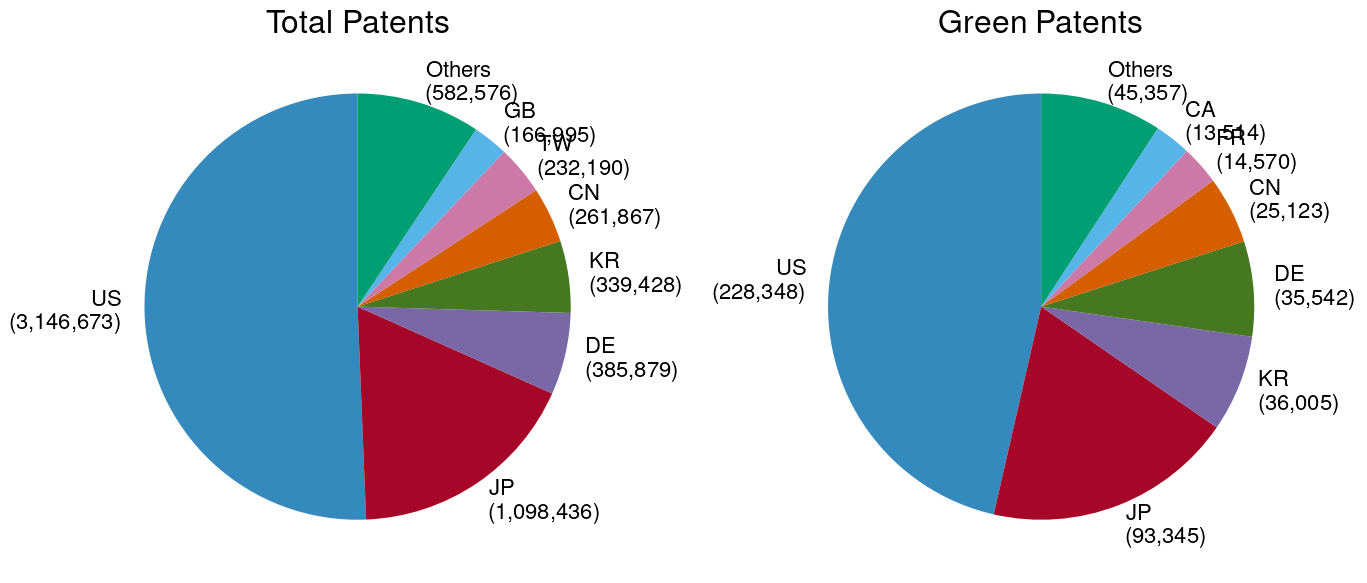

In [36]:
def autopct_format(pct, allvals):
    absolute = int(round(pct / 100. * sum(allvals)))
    return f"{pct:.1f}%\n({absolute:,})"

# -------------------------------
# 绘制两个饼图
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# 绘制 total_patents 饼图
labels_total = [f"{row['country']}\n({row['total_patents']:,})" 
                for _, row in total_data.iterrows()]
values_total = total_data['total_patents'].values

axes[0].pie(
    values_total,
    labels=labels_total,
    # autopct=lambda pct: autopct_format(pct, values_total),
    startangle=90
)
axes[0].set_title("Total Patents")

# 绘制 green_patents 饼图
labels_green = [f"{row['country']}\n({int(row['green_patents']):,})" 
                for _, row in g_data.iterrows()]
values_green = g_data['green_patents'].values

axes[1].pie(
    values_green,
    labels=labels_green,
    # autopct=lambda pct: autopct_format(pct, values_green),
    startangle=90
)
axes[1].set_title("Green Patents")

plt.tight_layout()
plt.show()


### Map